# EDA 2: Análisis de Correlaciones y Visualización

Este notebook tiene como objetivo principal explorar las relaciones entre las variables del dataset *California Housing*. Analizaremos la distribución geográfica, calcularemos matrices de correlación y visualizaremos cómo influyen características como el ingreso en el valor de las casas.

### 1. Configuración de Librerías y Estilo de Gráficos

Preparamos el entorno con las herramientas necesarias para el procesamiento de datos y la generación de visualizaciones de alta calidad.

In [1]:
# Importación de bibliotecas estándar para análisis de datos
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ajuste de parámetros globales para que las gráficas sean legibles y estéticas
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

### 2. Carga de Datos de Entrenamiento (Raw)

Utilizamos la ruta configurada en nuestro módulo central de configuración para cargar los datos que fueron separados previamente en el proceso de split.

In [2]:
# Cargamos la ruta del directorio de datos procesados (interim)
from housing.config import SPLIT_DIR

# Lectura del archivo CSV correspondiente al set de entrenamiento crudo
df_raw = pd.read_csv(SPLIT_DIR / "housing_train_raw.csv")

# Realizamos una copia profunda para evitar modificar accidentalmente el objeto original
df = df_raw.copy()

### 3. Inspección Inicial del Dataset

Revisamos la estructura y las primeras entradas para familiarizarnos con las columnas disponibles.

In [3]:
# Mostramos las primeras 5 filas para una inspección rápida de los valores y tipos de datos
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY
1,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN
2,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND
3,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND
4,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN


### 4. Distribución Geográfica de California

Graficamos la latitud y longitud para entender cómo se distribuyen las viviendas en el estado e identificar concentraciones poblacionales.

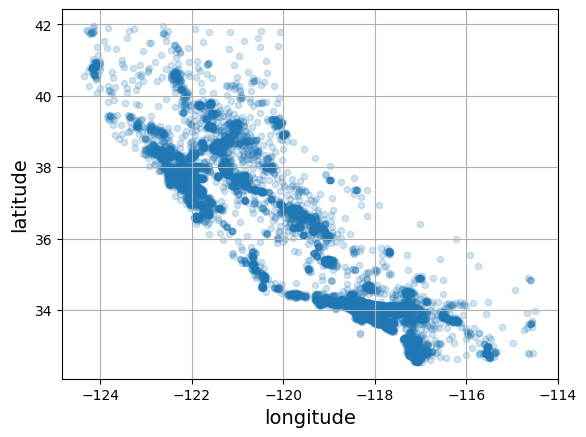

In [4]:
# Generamos un scatter plot geográfico. El parámetro alpha=0.2 ayuda a visualizar la densidad de puntos.
df.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

### 5. Coeficientes de Correlación de Pearson

Calculamos la correlación para identificar qué variables tienen una relación lineal fuerte entre sí.

In [5]:
# Calculamos la matriz utilizando solo las columnas numéricas para evitar errores de tipo
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924213,-0.102937,0.044558,0.068210,0.104236,0.054261,-0.016542,-0.050859
latitude,-0.924213,1.000000,0.005692,-0.036753,-0.066391,-0.115677,-0.071604,-0.078137,-0.139584
housing_median_age,-0.102937,0.005692,1.000000,-0.361710,-0.317978,-0.301906,-0.300075,-0.127043,0.102175
total_rooms,0.044558,-0.036753,-0.361710,1.000000,0.930076,0.863967,0.916143,0.197720,0.137455
total_bedrooms,0.068210,-0.066391,-0.317978,0.930076,1.000000,0.886200,0.978822,-0.006038,0.054635
population,0.104236,-0.115677,-0.301906,0.863967,0.886200,1.000000,0.916237,0.004282,-0.020153
households,0.054261,-0.071604,-0.300075,0.916143,0.978822,0.916237,1.000000,0.013637,0.071426
median_income,-0.016542,-0.078137,-0.127043,0.197720,-0.006038,0.004282,0.013637,1.000000,0.688380
median_house_value,-0.050859,-0.139584,0.102175,0.137455,0.054635,-0.020153,0.071426,0.688380,1.000000


### 6. Predictores del Valor Medio de la Vivienda

Filtramos la matriz para ver qué características influyen más positiva o negativamente en el precio.

In [6]:
# Ordenamos los valores de mayor a menor para identificar el predictor más relevante rápidamente
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

### 7. Visualización Multivariante: Matriz de Dispersión

Analizamos visualmente la interacción entre las variables que mostraron mayor correlación.

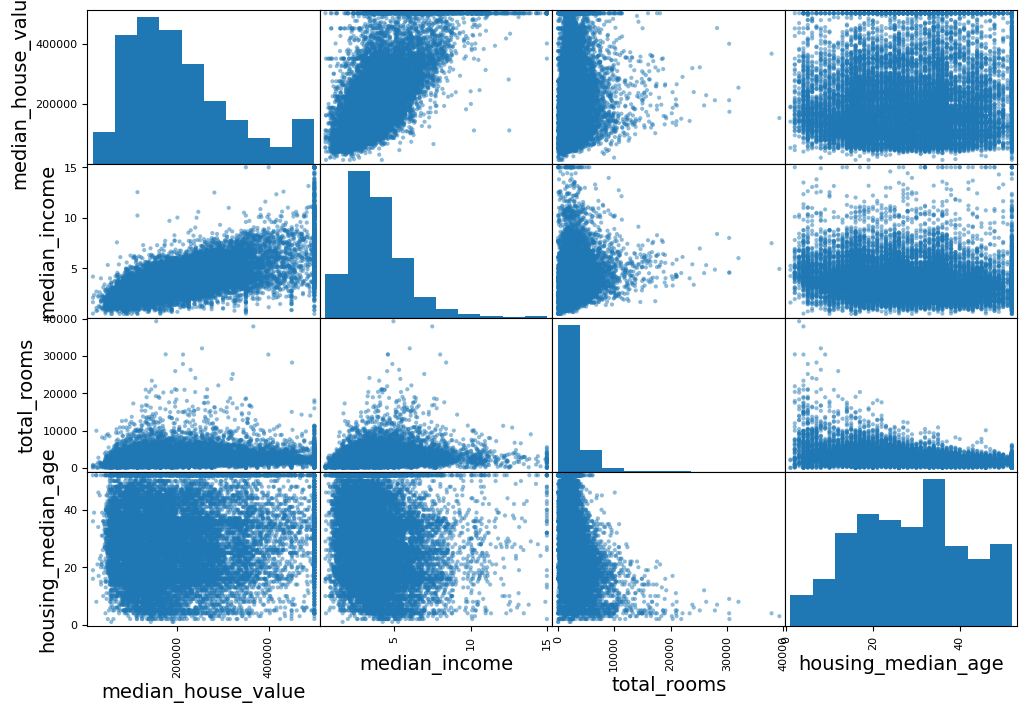

In [7]:
# Utilizamos scatter_matrix para ver la relación entre los atributos más prometedores del análisis anterior
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(df[attributes], figsize=(12, 8))
plt.show()

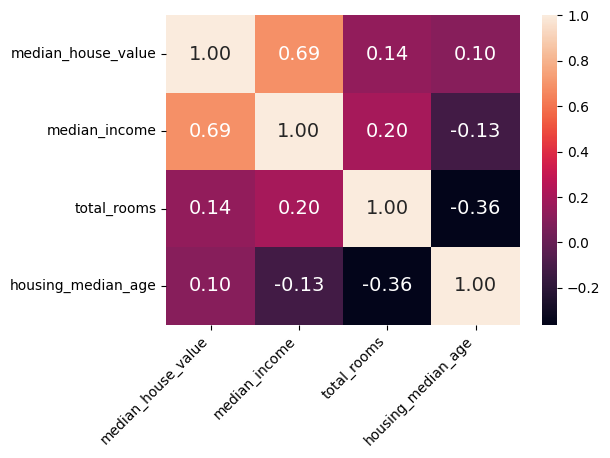

In [8]:
import seaborn as sns

corr = df[attributes].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 8. Análisis de Impacto del Ingreso Medio

Realizamos un análisis específico sobre el ingreso medio, ya que parece ser el factor más determinante para el valor de la vivienda.

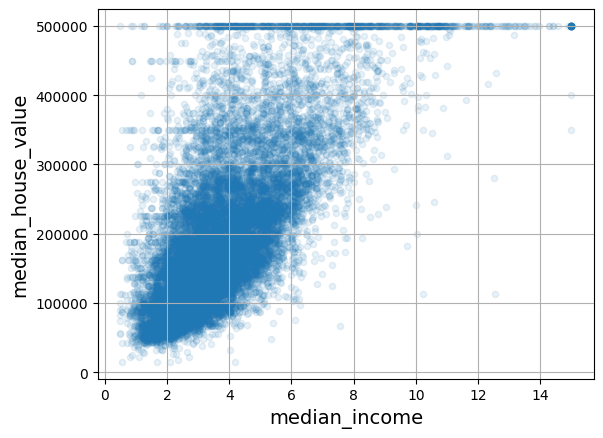

In [9]:
# Graficamos Ingreso vs Valor con baja opacidad para observar la tendencia y los topes de precio (500k)
df.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid=True)
plt.show()